# Importing Libraries

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input

In [22]:
input_shape = (416, 416, 3) 

In [10]:

# Define directories
train_dir = 'D:\\Kaggle\\Cataract\\train'

# Image Data Generator
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)


# Training and validation generators
train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary', # or 'categorical' if more than 2 classes
    subset='training'
)


Found 329 images belonging to 2 classes.


In [11]:
validation_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary', # or 'categorical' if more than 2 classes
    subset='validation'
)

Found 81 images belonging to 2 classes.


In [20]:

model = Sequential([
    Input(shape=(416, 416, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])


In [13]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy']) # Use 'categorical_crossentropy' if 'categorical'




In [14]:
train_generator.samples,train_generator.batch_size

(329, 32)

In [15]:
# Train the model
history = model.fit(
    train_generator,
    
    validation_data=validation_generator,
    epochs=50
)

Epoch 1/50
11/11 [==============================] - 10s 691ms/step - loss: 1.2523 - accuracy: 0.5137 - val_loss: 0.6869 - val_accuracy: 0.5185
Epoch 2/50
11/11 [==============================] - 7s 603ms/step - loss: 0.6946 - accuracy: 0.5258 - val_loss: 0.6843 - val_accuracy: 0.6667
Epoch 3/50
11/11 [==============================] - 7s 617ms/step - loss: 0.6634 - accuracy: 0.6657 - val_loss: 0.6205 - val_accuracy: 0.6667
Epoch 4/50
11/11 [==============================] - 7s 649ms/step - loss: 0.5996 - accuracy: 0.6748 - val_loss: 0.6171 - val_accuracy: 0.7284
Epoch 5/50
11/11 [==============================] - 8s 686ms/step - loss: 0.5223 - accuracy: 0.7629 - val_loss: 0.5250 - val_accuracy: 0.7160
Epoch 6/50
11/11 [==============================] - 7s 671ms/step - loss: 0.6285 - accuracy: 0.7447 - val_loss: 0.5257 - val_accuracy: 0.7531
Epoch 7/50
11/11 [==============================] - 8s 678ms/step - loss: 0.4995 - accuracy: 0.7872 - val_loss: 0.5676 - val_accuracy: 0.7407
Epoch

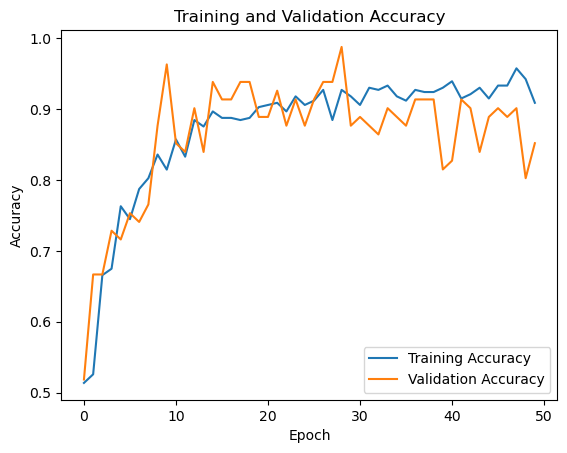

In [17]:
# 1st
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
plt.figure()
plt.plot( train_acc, label='Training Accuracy')
plt.plot( val_acc, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

In [42]:
model.save('model.h5')

In [18]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 148, 148, 32)      896       
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 74, 74, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_4 (Conv2D)           (None, 72, 72, 64)        18496     
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 36, 36, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_5 (Conv2D)           (None, 34, 34, 128)       73856     
                                                                 
 max_pooling2d_5 (MaxPoolin  (None, 17, 17, 128)      